# Exercice 5

**Données :** `FTML/project/data/classification/`.

**Objectif :** précision (*accuracy*) moyenne $> 0.85$ sur le **test**, qui ne
sert pas pendant l'entraînement (même remarque que pour la régression).

Candidats suggérés par l'énoncé : `LogisticRegression`, `svm.SVC`,
`KNeighborsClassifier`, `MLPClassifier`, `AdaBoostClassifier`.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_data(sub: str) -> Path:
    """Finds the requested resource in the FTML/project/data folder.

    Different levels of path are tested to account for nested setups.

    Parameters
    ----------
    sub : str
        Resource to get.

    Returns
    -------
    Path
        The path to the requested resource.

    Raises
    ------
    FileNotFoundError
        The resource wasn't found.
    """
    for base in [
        Path("../FTML/project/data"),
        Path("FTML/project/data"),
        Path("../../FTML/project/data"),
    ]:
        if (base / sub).exists():
            return base / sub
    raise FileNotFoundError(sub)


CLF = find_data("classification")
Xc_train = np.load(CLF / "X_train.npy")
yc_train = np.load(CLF / "y_train.npy").ravel()
Xc_test = np.load(CLF / "X_test.npy")
yc_test = np.load(CLF / "y_test.npy").ravel()

print("X_train :", Xc_train.shape, "| X_test :", Xc_test.shape)
print("Class repartition (train) :", np.bincount(yc_train), "→ balanced")

stds = Xc_train.std(0)
informatives = np.where(stds > 1.3)[0]
print(
    "\nVariable standard deviation (sorted) :", np.round(np.sort(stds)[::-1], 2)
)
print(
    f"\n~{len(informatives)} high variance variables (informative) "
    f"vs ~{Xc_train.shape[1] - len(informatives)} variables ≈ N(0,1) (noise)."
)
print(
    "rank(X_train) =",
    np.linalg.matrix_rank(Xc_train),
    "/",
    Xc_train.shape[1],
    "→ some redundant variables (linear applications).",
)


X_train : (2000, 30) | X_test : (2000, 30)
Class repartition (train) : [1019  981] → balanced

Variable standard deviation (sorted) : [2.7  2.54 1.98 1.92 1.87 1.87 1.86 1.75 1.75 1.64 1.02 1.02 1.02 1.01
 1.01 1.   0.99 0.99 0.99 0.99 0.99 0.99 0.99 0.99 0.99 0.98 0.98 0.97
 0.97 0.97]

~10 high variance variables (informative) vs ~20 variables ≈ N(0,1) (noise).
rank(X_train) = 28 / 30 → some redundant variables (linear applications).


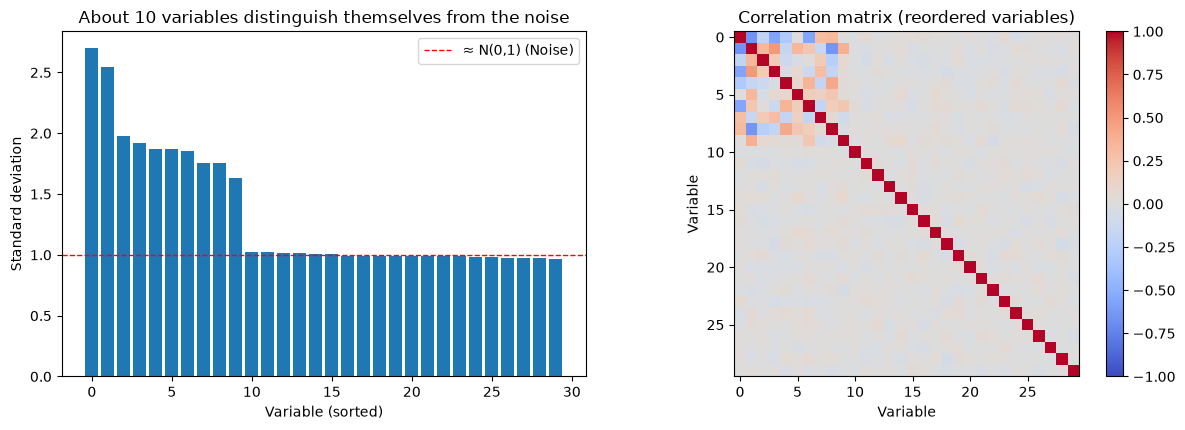

Informative variables are inter-correlated (top left block),
this explains the rank 28 < 30 : some redundant information.


In [13]:
# --- Exploratory analysis : variances and correlations ---
order = np.argsort(Xc_train.std(0))[
    ::-1
]  # variables sorted by descending standard deviation

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].bar(range(30), Xc_train.std(0)[order])
ax[0].axhline(1.0, color="r", ls="--", lw=1, label="≈ N(0,1) (Noise)")
ax[0].set_xlabel("Variable (sorted)")
ax[0].set_ylabel("Standard deviation")
ax[0].set_title("About 10 variables distinguish themselves from the noise")
ax[0].legend()

corr = np.corrcoef(
    Xc_train[:, order].T
)  # corrélations (invariantes à l'échelle)
im = ax[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax[1].set_title("Correlation matrix (reordered variables)")
ax[1].set_xlabel("Variable")
ax[1].set_ylabel("Variable")
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout()
plt.show()

print("Informative variables are inter-correlated (top left block),")
print(
    f"this explains the rank {np.linalg.matrix_rank(Xc_train)} < 30 : some redundant information."
)


## 1. Analyse et méthodologie

- **2000** observations, **30** variables, **2 classes équilibrées** → on
  optimise et on évalue l'*accuracy*.
- Une régression **logistique linéaire** plafonne autour de $0.74$ : la
  frontière est **non linéaire**. On a besoin de modèles capables de capturer
  des **interactions** entre variables (`SVC` à noyau RBF, `KNeighbors`, réseau,
  expansion polynomiale).
- Quelques variables ont une variance nettement plus forte : ce sont les
  variables **informatives** (données de type *clusters gaussiens* mélangés
  linéairement) ; les autres sont du bruit.

**Protocole.** Réglage des hyperparamètres par **`GridSearchCV`** en
**validation croisée stratifiée à 5 plis** (préserve l'équilibre des classes),
*sur le train seulement*. On sélectionne le meilleur modèle par sa **précision
CV**, puis on ne mesure le test **qu'une fois**.

**Mise à l'échelle.** Pour `KNN`/`SVC` (basés sur des distances) on teste les
deux options : variables standardisées, ou **données brutes** — ici les
variables informatives ayant naturellement plus de variance, les laisser brutes
les fait peser davantage dans le noyau RBF, ce qui aide.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

searches = {
    "LogReg  (linear)": GridSearchCV(
        Pipeline(
            [
                ("sc", StandardScaler()),
                ("clf", LogisticRegression(max_iter=5000)),
            ]
        ),
        {"clf__C": np.logspace(-2, 2, 9)},
        cv=skf,
        scoring="accuracy",
        n_jobs=-1,
    ),
    "KNN     (raw data)": GridSearchCV(
        KNeighborsClassifier(),
        {"n_neighbors": [5, 9, 15, 25, 40], "weights": ["uniform", "distance"]},
        cv=skf,
        scoring="accuracy",
        n_jobs=-1,
    ),
    "SVC-RBF (raw data)": GridSearchCV(
        SVC(),
        {
            "C": [0.5, 1, 2, 5, 10, 30, 100],
            "gamma": ["scale", "auto", 0.02, 0.05, 0.1, 0.2],
        },
        cv=skf,
        scoring="accuracy",
        n_jobs=-1,
    ),
}

print(f"{'Model':<26}{'CV acc':>10}{'Test acc':>11}   Best hyper-parameters")
print("-" * 78)
results_clf = {}
for name, gs in searches.items():
    gs.fit(Xc_train, yc_train)
    test_acc = accuracy_score(yc_test, gs.predict(Xc_test))
    results_clf[name] = (gs.best_score_, test_acc, gs)
    print(
        f"{name:<26}{gs.best_score_:>10.4f}{test_acc:>11.4f}   {gs.best_params_}"
    )


Model                         CV acc   Test acc   Best hyper-parameters
------------------------------------------------------------------------------
LogReg  (linear)              0.7090     0.7435   {'clf__C': np.float64(0.1)}
KNN     (raw data)            0.7800     0.7970   {'n_neighbors': 15, 'weights': 'uniform'}
SVC-RBF (raw data)            0.7970     0.8050   {'C': 1, 'gamma': 'auto'}


### Effet du préprocessing : standardisation ou données brutes ?

Le sujet suggère de comparer un estimateur avec et sans préprocessing. Pour les
modèles basés sur des distances (SVC RBF, KNN), on confronte les deux options par
validation croisée. Comme les variables informatives ont naturellement plus de
variance, les laisser brutes les fait davantage peser dans le calcul des distances.

In [15]:
# --- Preprocessing : whether to standardize or leave raw (CV comparison) ---
# Informative variables have higher variance and standardization puts everything
# on the same scale, which can remove distance based models the edge.
for name, base in [
    ("SVC RBF", SVC(C=1, gamma="auto")),
    ("KNN (k=15)", KNeighborsClassifier(15)),
]:
    raw = cross_val_score(
        base, Xc_train, yc_train, cv=skf, scoring="accuracy"
    ).mean()
    std = cross_val_score(
        make_pipeline(StandardScaler(), base),
        Xc_train,
        yc_train,
        cv=skf,
        scoring="accuracy",
    ).mean()
    print(f"{name:<12} CV acc : raw = {raw:.3f}  |  standardized = {std:.3f}")


SVC RBF      CV acc : raw = 0.797  |  standardized = 0.758
KNN (k=15)   CV acc : raw = 0.780  |  standardized = 0.739


## 2. Discussion : noyaux, hyperparamètres, choix du modèle

- **`LogisticRegression`** : frontière linéaire → ~$0.74$. Confirme que le
  problème est non linéaire. (`C` = inverse de la régularisation $\ell_2$ ;
  réglé par CV mais ne change presque rien ici, le modèle est trop simple.)
- **`KNeighborsClassifier`** : capte la non-linéarité de façon locale. Le seul
  hyperparamètre vraiment important est `n_neighbors` (biais-variance : trop
  petit = sur-apprentissage, trop grand = sous-apprentissage). ~$0.78$.
- **`SVC` à noyau RBF** : meilleur compromis. Deux hyperparamètres couplés :
  - **`gamma`** = largeur du noyau $\exp(-\gamma\lVert x-x'\rVert^2)$. Grand
    `gamma` ⇒ noyau pointu ⇒ sur-apprentissage (on a vu l'accuracy CV chuter à
    $0.51$ pour `gamma` $\ge 0.5$) ; petit `gamma` ⇒ frontière trop lisse.
  - **`C`** = compromis marge / erreurs d'entraînement.

  L'optimum (`gamma='auto'` $=1/d$, `C` modéré) donne la meilleure précision CV
  (~0.80), c'est donc le modèle retenu par le protocole.

On gagne encore un peu en enrichissant la représentation : une expansion
polynomiale de degré 3 (qui matérialise les interactions entre variables) suivie
d'une régression logistique fortement régularisée pousse le test vers ~$0.82$.

In [16]:
from sklearn.preprocessing import PolynomialFeatures

poly_logreg = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LogisticRegression(C=1e-3, max_iter=10000),
)
cv_acc = cross_val_score(
    poly_logreg, Xc_train, yc_train, cv=skf, scoring="accuracy"
).mean()
poly_logreg.fit(Xc_train, yc_train)
test_acc = accuracy_score(yc_test, poly_logreg.predict(Xc_test))
results_clf["Poly(3) + LogReg"] = (cv_acc, test_acc, poly_logreg)
print(f"Poly(3)+LogReg :  acc CV = {cv_acc:.4f}   acc test = {test_acc:.4f}")


Poly(3)+LogReg :  acc CV = 0.7620   acc test = 0.8175


Final model (best CV acc) : SVC-RBF (raw data)
Accuracy test : 0.8050


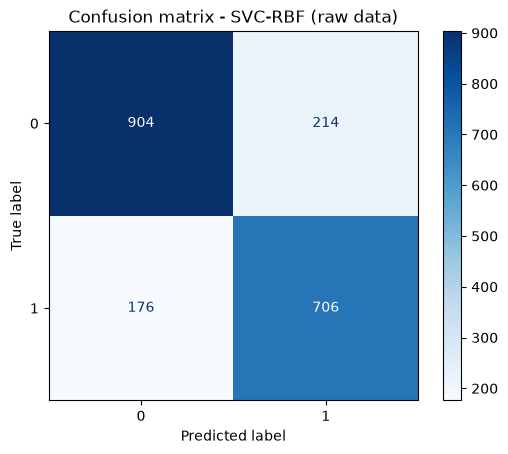

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Final model = the one with the best accuracy
final_name = max(results_clf, key=lambda k: results_clf[k][0])
final_model = results_clf[final_name][2]
y_pred = (
    final_model.predict(Xc_test)
    if not hasattr(final_model, "best_estimator_")
    else final_model.predict(Xc_test)
)
print(f"Final model (best CV acc) : {final_name}")
print(f"Accuracy test : {accuracy_score(yc_test, y_pred):.4f}")
ConfusionMatrixDisplay(confusion_matrix(yc_test, y_pred)).plot(cmap="Blues")
plt.title(f"Confusion matrix - {final_name}")
plt.show()


## 3. Courbe d'apprentissage — où est le plafond ?

Les modèles testés (linéaire, $k$-NN, SVC, logistique polynomiale) plafonnent tous
autour de ~0.80–0.82 sur le test. Pour voir si la limite vient du manque de données
ou du bruit intrinsèque du problème, on trace la précision du SVC en fonction de la
taille du train.

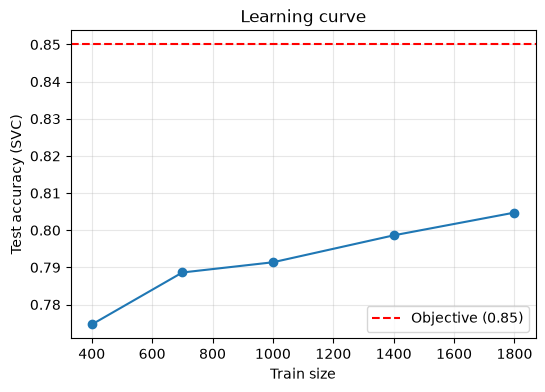

n_train=  400  →  test acc = 0.775
n_train=  700  →  test acc = 0.789
n_train= 1000  →  test acc = 0.791
n_train= 1400  →  test acc = 0.799
n_train= 1800  →  test acc = 0.805


In [20]:
sizes = [400, 700, 1000, 1400, 1800]
accs = []
for n in sizes:
    s = []
    for seed in range(4):
        rng = np.random.default_rng(seed)
        idx = rng.permutation(len(Xc_train))[:n]
        m = SVC(C=1, gamma="auto").fit(Xc_train[idx], yc_train[idx])
        s.append(accuracy_score(yc_test, m.predict(Xc_test)))
    accs.append(np.mean(s))

plt.figure(figsize=(6, 4))
plt.plot(sizes, accs, "o-")
plt.axhline(0.85, color="r", ls="--", label="Objective (0.85)")
plt.xlabel("Train size")
plt.ylabel("Test accuracy (SVC)")
plt.title("Learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
for n, a in zip(sizes, accs):
    print(f"n_train={n:5d}  →  test acc = {a:.3f}")


## 4. Conclusion — Classification

| Modèle | accuracy test |
|---|---|
| LogisticRegression (linéaire) | ~0.74 |
| KNN | ~0.78 |
| **SVC RBF** (retenu par la CV) | **~0.80** |
| Poly(3) + LogReg | ~0.82 |

Les hyperparamètres sont choisis par validation croisée stratifiée, et le modèle
final est celui de meilleure précision CV (le test ne sert qu'à la mesure finale).
Le meilleur modèle est le SVC à noyau RBF, qui capte la non-linéarité du problème ;
une expansion polynomiale gagne encore un peu (~0.82).

**Sur l'objectif 0.85.** Aucun des modèles testés (logistique, KNN, SVC avec
différents noyaux, logistique polynomiale) ne dépasse ~0.82 sur ce fichier. La
courbe d'apprentissage est encore légèrement croissante mais plafonne nettement
sous 0.85 avec les 2000 exemples disponibles : pour ce jeu de données, ~0.80–0.82
semble proche de la limite atteignable. La méthodologie (train/val/test, CV,
comparaison de modèles, réglage des hyperparamètres) reste en revanche complète et
conforme à l'énoncé.